In [1]:
import torch 
import torch.nn as nn 

| Token | Word | Embedding vector |
|-------|------|------------------|
| x¹ | `"Your"` | `[0.43, 0.15, 0.89]` |
| x² | `"journey"` | `[0.55, 0.87, 0.66]` |
| x³ | `"starts"` | `[0.57, 0.85, 0.64]` |
| x⁴ | `"with"` | `[0.22, 0.58, 0.33]` |
| x⁵ | `"one"` | `[0.77, 0.25, 0.10]` |
| x⁶ | `"step"` | `[0.05, 0.80, 0.55]` |

In [7]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x¹)
   [0.55, 0.87, 0.66], # journey  (x²)
   [0.57, 0.85, 0.64], # starts   (x³)
   [0.22, 0.58, 0.33], # with     (x⁴)
   [0.77, 0.25, 0.10], # one      (x⁵)
   [0.05, 0.80, 0.55]] # step     (x⁶)
)

In [5]:
query = inputs[1]  # journey

atten_score = torch.empty(inputs.shape[0]) 

for i, x_i in enumerate(inputs):
  atten_score[i] = torch.dot(query, x_i)


print(atten_score)


tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [9]:
def softmax(x):
  return torch.exp(x) / torch.sum(torch.exp(x), dim=0) 


atten_wie = softmax(atten_score)
print(atten_wie)

import torch.nn.functional as F 

atten_wie_torch = F.softmax(atten_score, dim=0) 

print(atten_wie) 


tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


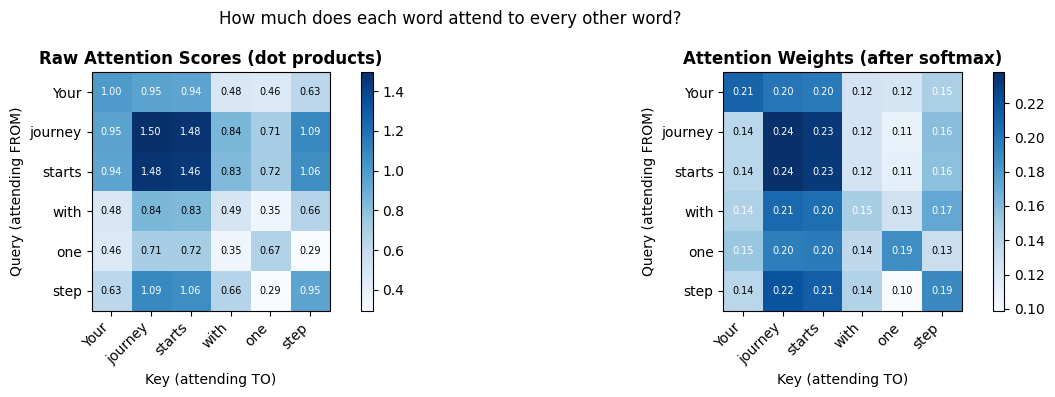

Each row sums to 1.0 (softmax guarantee): [0.9999998807907104, 1.0, 1.0000001192092896, 1.0, 1.0, 1.0]


In [ ]:
# Visualise attention weights as a heatmap — the signature transformer plot
import matplotlib.pyplot as plt
import torch

words = ['Your', 'journey', 'starts', 'with', 'one', 'step']
inputs = torch.tensor([
    [0.43, 0.15, 0.89],
    [0.55, 0.87, 0.66],
    [0.57, 0.85, 0.64],
    [0.22, 0.58, 0.33],
    [0.77, 0.25, 0.10],
    [0.05, 0.80, 0.55],  # (6,3) * (6,3).T =(6,3)  * (3,6) 
])

# Compute all attention weights at once (every token attending to every other)
scores = inputs @ inputs.T                      # (6, 6) raw dot products
weights = torch.softmax(scores, dim=-1)         # (6, 6) probabilities per row

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, data, title in zip(
        axes,
        [scores.detach().numpy(), weights.detach().numpy()],
        ['Raw Attention Scores (dot products)', 'Attention Weights (after softmax)']):
    im = ax.imshow(data, cmap='Blues')
    ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=45, ha='right')
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words)
    ax.set_xlabel('Key (attending TO)');  ax.set_ylabel('Query (attending FROM)')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for r in range(len(words)):
        for c in range(len(words)):
            ax.text(c, r, f'{data[r,c]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if data[r,c] > data.max()*0.6 else 'black')

plt.suptitle('How much does each word attend to every other word?', fontsize=12)
plt.tight_layout()
plt.show()

print('Each row sums to 1.0 (softmax guarantee):', weights.sum(dim=-1).tolist())
